# Global Happiness vs Undernourishment Analysis

## Objetivo
Analisar a relação entre o índice de felicidade dos países e a taxa de desnutrição ao longo do tempo, identificando padrões e possíveis correlações.

## Fonte dos dados
- World Happiness Report (2005–2025)
- Undernourishment Dataset (2000–2024)

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carregamento dos dados

In [54]:
happiness = pd.read_csv('data/world_happiness_report_2005_2025.csv')
undernourishment = pd.read_csv('data/prevalence-of-undernourishment.csv')

## Exploração inicial dos dados

In [55]:
happiness.head()
undernourishment.head()

,Entity,Code,Year,2.1.1 prevalence of undernourishment - Value (percent)
0,Afghanistan,AFG,2001,45.8
1,Afghanistan,AFG,2002,43.5
2,Afghanistan,AFG,2003,38.7
3,Afghanistan,AFG,2004,34.6
4,Afghanistan,AFG,2005,30.6


In [56]:
happiness.info()
undernourishment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   str    
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float64
 12  dys

## Limpeza e preparação dos dados
Padronização dos nomes das colunas para possibilitar o merge.

In [57]:
undernourishment = undernourishment.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    '2.1.1 prevalence of undernourishment - Value (percent)': 'undernourishment_rate'
})

## 🔗 Integração dos datasets

In [58]:
df = pd.merge(
    happiness,
    undernourishment,
    on=['country', 'year'],
    how='inner'
)

df.head()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual,Code,undernourishment_rate
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DNK,2.5
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FIN,2.5
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOR,2.5
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NLD,2.5
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CAN,2.5


## Análise exploratória

In [59]:
df[['happiness_score', 'undernourishment_rate']].corr()

,happiness_score,undernourishment_rate
happiness_score,1.000000,-0.611054
undernourishment_rate,-0.611054,1.000000


## Relação entre felicidade e desnutrição

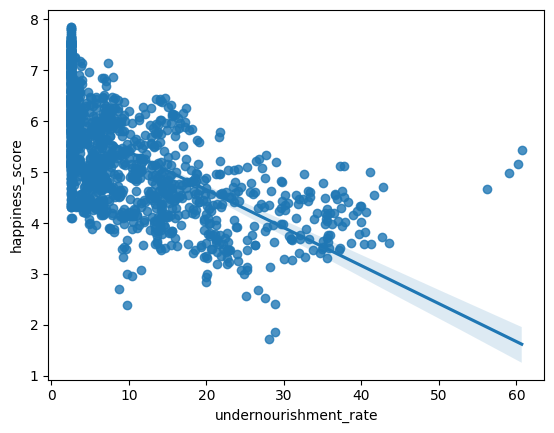

In [60]:
sns.regplot(
    data=df,
    x='undernourishment_rate',
    y='happiness_score'
)

plt.show()

## Insights

- Observa-se uma correlação negativa entre a taxa de desnutrição e o índice de felicidade.
- Países com menor desnutrição tendem a apresentar maiores níveis de felicidade.
- Existem exceções, indicando que outros fatores também influenciam o bem-estar.

## Conclusão

A análise sugere que a insegurança alimentar está associada a níveis mais baixos de felicidade. 
No entanto, a felicidade é um fenômeno multifatorial, sendo influenciada também por aspectos econômicos, sociais e políticos.